### Datos Sintéticos
### Librería SDV
*Fecha: 05 de junio*

*Autor: Fernando Torres Zonahua*

In [2]:
# Importamos librerias básicas
import pandas as pd
import numpy as np
import random

In [3]:
# Importamos librerias para datos sintéticos
import sdv
import sdmetrics

In [4]:
# Importamos sublibrerias para la generación de datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [5]:
# Importamos sublibrerias para la evaluación de los datos
from sdmetrics.reports.single_table import QualityReport

In [7]:
print("SDV: ", sdv.__version__)
print("SDMetrics: ", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics:  0.28.0


# Crear una tabla de datos REAL como base para la generación de Datos Sintéticos
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad" : [17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual" : [1800,2000,2500,15000,18000,35000,7000,15000,4000,5000],
        "ciudades" : ["Potrero Nuevo", "Atoyac", "Cuichapa", "Córdoba", "Cuitláhuac", "Orizaba", "Paraje", "Yanga", "Tierra Blanca", "Calcahualco"]
    }
)

In [9]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudades
0,1,17,1800,Potrero Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Córdoba
4,5,32,18000,Cuitláhuac
5,6,42,35000,Orizaba
6,7,70,7000,Paraje
7,8,28,15000,Yanga
8,9,23,4000,Tierra Blanca
9,10,22,5000,Calcahualco


### Obtener los metadata del DataFrame generado

In [11]:
# Creamos una instancia de SingleTableMetadata
metadata = SingleTableMetadata()

In [12]:
metadata.detect_from_dataframe(
    data= dfClientes
)

In [13]:
metadata.to_dict()

{'primary_key': 'cliente_id',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudades': {'sdtype': 'categorical'}}}

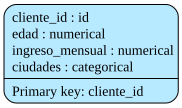

In [16]:
metadata.visualize()

### Entrenar el modelo de datos sintéticos
*Un sinthetisizer es el encargado de generar los datos sintéticos*

In [18]:
#Le pasamos los metadatos
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\torre\anaconda3\envs\Extraccion9AVS\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\torre\anaconda3\envs\Extraccion9AVS\Lib\site-packages\sdv\single_table\base.py:138: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [19]:
# Entrenamos el sintetizador con los datos "REALES"
sintetizador.fit(
    dfClientes
)

In [22]:
#Generamos los datos sintéticos
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [23]:
dfClientes_falsos

,cliente_id,edad,ingreso_mensual,ciudades
0,9377199,18,2210,Potrero Nuevo
1,2031974,18,3912,Orizaba
2,5464438,18,2183,Cuichapa
3,3224426,18,3489,Orizaba
4,1760189,23,13143,Potrero Nuevo
...,...,...,...,...
195,15922112,26,6533,Cuitláhuac
196,7891214,20,10783,Orizaba
197,3545532,51,23991,Calcahualco
198,15420883,26,5723,Yanga


In [24]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudades         200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [25]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,10530.000000
std,3.02765,16.063762,10507.568701
min,1.00000,17.000000,1800.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,6000.000000
75%,7.75000,31.000000,15000.000000
max,10.00000,70.000000,35000.000000


In [26]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,7.964678e+06,26.775000,11213.915000
std,4.867522e+06,12.895575,9039.904128
min,1.896240e+05,18.000000,2000.000000
25%,3.527745e+06,18.000000,3240.750000
50%,7.562856e+06,20.000000,9303.000000
75%,1.269630e+07,30.750000,16951.500000
max,1.673568e+07,70.000000,35000.000000


### Evaluamos los datos para validar
1. Similtud entre las columnas (Columns Shapes Score)
2. Similitud entre las relaciones de las columnas (Evaluating Column Per Trends)
3. Evaluación del dataset general

In [27]:
# Evaluamos la calidad de los datos
# Creamos una instancia de QualityReport
reporte = QualityReport()

### Puntos de referencia
|Score    | Interpretación |
|---------|----------------|
|1    | Identicas |
|0.9  | Muy similar |
|0.7  | Similar |
|0.6  | Diferencias visibles |
|< 0.5 | Muy diferentes |

In [28]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 282.68it/s]|
Column Shapes Score: 79.5%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 99.43it/s]|
Column Pair Trends Score: 21.25%

Overall Score (Average): 50.38%

